In [ ]:
# https://figshare.com/ndownloader/files/63460149
import requests
import zipfile
import io
import os

url = "https://figshare.com/ndownloader/files/63460149"

response = requests.get(url)
response.raise_for_status() 

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall(os.getcwd())

print("Download and extraction complete.")

In [15]:
import numpy as np
import json

# -----------------------------
# 1. Load previously saved JSON files
# -----------------------------
with open("tappi_true.json", "r") as f:
    y_true = np.array(json.load(f))

with open("tappi_pred.json", "r") as f:
    y_pred = np.array(json.load(f))

# Define class labels
labels = [0, 1, 2, 3]
num_classes = len(labels)

# -----------------------------
# 2. Build confusion matrix
# -----------------------------
conf_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

# Row sum (support) and column sum
support = conf_mat.sum(axis=1)
col_total = conf_mat.sum(axis=0)

# -----------------------------
# 3. Compute Precision, Recall, F1
# -----------------------------
precision = np.zeros(num_classes)
recall = np.zeros(num_classes)
f1 = np.zeros(num_classes)

for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# -----------------------------
# 4. Overall accuracy
# -----------------------------
accuracy = conf_mat.diagonal().sum() / conf_mat.sum()

# -----------------------------
# 5. Normalized confusion matrix
# -----------------------------
conf_mat_norm = conf_mat.astype(float) / support[:, None]

# -----------------------------
# 6. Per-class Matthews Correlation Coefficient
# -----------------------------
mcc = np.zeros(num_classes)
for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    TN = conf_mat.sum() - (TP + FP + FN)
    numerator = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc[i] = numerator / denominator if denominator > 0 else 0

# -----------------------------
# 7. Print results
# -----------------------------
print("Integer Confusion Matrix:\n", conf_mat)
print("\nNormalized Confusion Matrix (4 decimals):\n", np.round(conf_mat_norm, 4))
print("\nNormalized Confusion Matrix (2 decimals):\n", np.round(conf_mat_norm, 2))

print("\nPer-class metrics:")
for i, l in enumerate(labels):
    print(f"Class {l}: precision={precision[i]:.4f}, recall={recall[i]:.4f}, f1={f1[i]:.4f}, mcc={mcc[i]:.4f}")

print("\nOverall Accuracy:", accuracy)

Integer Confusion Matrix:
 [[ 796  300  213   23]
 [ 160  746   66  116]
 [  61   24 2421   21]
 [  22  182   73  811]]

Normalized Confusion Matrix (4 decimals):
 [[0.5976 0.2252 0.1599 0.0173]
 [0.1471 0.6857 0.0607 0.1066]
 [0.0241 0.0095 0.9581 0.0083]
 [0.0202 0.1673 0.0671 0.7454]]

Normalized Confusion Matrix (2 decimals):
 [[0.6  0.23 0.16 0.02]
 [0.15 0.69 0.06 0.11]
 [0.02 0.01 0.96 0.01]
 [0.02 0.17 0.07 0.75]]

Per-class metrics:
Class 0: precision=0.7661, recall=0.5976, f1=0.6714, mcc=0.5997
Class 1: precision=0.5958, recall=0.6857, f1=0.6376, mcc=0.5531
Class 2: precision=0.8731, recall=0.9581, f1=0.9136, mcc=0.8491
Class 3: precision=0.8352, recall=0.7454, f1=0.7878, mcc=0.7460

Overall Accuracy: 0.7910521955260977


In [13]:
import numpy as np
import json

# -----------------------------
# 1. Load previously saved JSON files
# -----------------------------
with open("revert_backbone_true.json", "r") as f:
    y_true = np.array(json.load(f))

with open("revert_backbone_pred.json", "r") as f:
    y_pred = np.array(json.load(f))

# Define class labels
labels = [0, 1, 2, 3]
num_classes = len(labels)

# -----------------------------
# 2. Build confusion matrix
# -----------------------------
conf_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

# Row sum (support) and column sum
support = conf_mat.sum(axis=1)
col_total = conf_mat.sum(axis=0)

# -----------------------------
# 3. Compute Precision, Recall, F1
# -----------------------------
precision = np.zeros(num_classes)
recall = np.zeros(num_classes)
f1 = np.zeros(num_classes)

for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# -----------------------------
# 4. Overall accuracy
# -----------------------------
accuracy = conf_mat.diagonal().sum() / conf_mat.sum()

# -----------------------------
# 5. Normalized confusion matrix
# -----------------------------
conf_mat_norm = conf_mat.astype(float) / support[:, None]

# -----------------------------
# 6. Per-class Matthews Correlation Coefficient
# -----------------------------
mcc = np.zeros(num_classes)
for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    TN = conf_mat.sum() - (TP + FP + FN)
    numerator = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc[i] = numerator / denominator if denominator > 0 else 0

# -----------------------------
# 7. Print results
# -----------------------------
print("Integer Confusion Matrix:\n", conf_mat)
print("\nNormalized Confusion Matrix (4 decimals):\n", np.round(conf_mat_norm, 4))
print("\nNormalized Confusion Matrix (2 decimals):\n", np.round(conf_mat_norm, 2))

print("\nPer-class metrics:")
for i, l in enumerate(labels):
    print(f"Class {l}: precision={precision[i]:.4f}, recall={recall[i]:.4f}, f1={f1[i]:.4f}, mcc={mcc[i]:.4f}")

print("\nOverall Accuracy:", accuracy)

Integer Confusion Matrix:
 [[ 432   58  107   38]
 [ 126  193   35  141]
 [  52   23 1171   37]
 [  51  100   39  305]]

Normalized Confusion Matrix (4 decimals):
 [[0.6803 0.0913 0.1685 0.0598]
 [0.2545 0.3899 0.0707 0.2848]
 [0.0405 0.0179 0.9127 0.0288]
 [0.103  0.202  0.0788 0.6162]]

Normalized Confusion Matrix (2 decimals):
 [[0.68 0.09 0.17 0.06]
 [0.25 0.39 0.07 0.28]
 [0.04 0.02 0.91 0.03]
 [0.1  0.2  0.08 0.62]]

Per-class metrics:
Class 0: precision=0.6536, recall=0.6803, f1=0.6667, mcc=0.5713
Class 1: precision=0.5160, recall=0.3899, f1=0.4442, mcc=0.3535
Class 2: precision=0.8661, recall=0.9127, f1=0.8888, mcc=0.7977
Class 3: precision=0.5854, recall=0.6162, f1=0.6004, mcc=0.5161

Overall Accuracy: 0.7224896836313618


In [12]:
import numpy as np
import json

# -----------------------------
# 1. Load previously saved JSON files
# -----------------------------
with open("replace_esm_true.json", "r") as f:
    y_true = np.array(json.load(f))

with open("replace_esm_pred.json", "r") as f:
    y_pred = np.array(json.load(f))

# Define class labels
labels = [0, 1, 2, 3]
num_classes = len(labels)

# -----------------------------
# 2. Build confusion matrix
# -----------------------------
conf_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

# Row sum (support) and column sum
support = conf_mat.sum(axis=1)
col_total = conf_mat.sum(axis=0)

# -----------------------------
# 3. Compute Precision, Recall, F1
# -----------------------------
precision = np.zeros(num_classes)
recall = np.zeros(num_classes)
f1 = np.zeros(num_classes)

for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# -----------------------------
# 4. Overall accuracy
# -----------------------------
accuracy = conf_mat.diagonal().sum() / conf_mat.sum()

# -----------------------------
# 5. Normalized confusion matrix
# -----------------------------
conf_mat_norm = conf_mat.astype(float) / support[:, None]

# -----------------------------
# 6. Per-class Matthews Correlation Coefficient
# -----------------------------
mcc = np.zeros(num_classes)
for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    TN = conf_mat.sum() - (TP + FP + FN)
    numerator = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc[i] = numerator / denominator if denominator > 0 else 0

# -----------------------------
# 7. Print results
# -----------------------------
print("Integer Confusion Matrix:\n", conf_mat)
print("\nNormalized Confusion Matrix (4 decimals):\n", np.round(conf_mat_norm, 4))
print("\nNormalized Confusion Matrix (2 decimals):\n", np.round(conf_mat_norm, 2))

print("\nPer-class metrics:")
for i, l in enumerate(labels):
    print(f"Class {l}: precision={precision[i]:.4f}, recall={recall[i]:.4f}, f1={f1[i]:.4f}, mcc={mcc[i]:.4f}")

print("\nOverall Accuracy:", accuracy)

Integer Confusion Matrix:
 [[ 347   73  114  132]
 [  77  129   38  300]
 [ 110    0 1072   77]
 [  77  163   39  269]]

Normalized Confusion Matrix (4 decimals):
 [[0.521  0.1096 0.1712 0.1982]
 [0.1415 0.2371 0.0699 0.5515]
 [0.0874 0.     0.8515 0.0612]
 [0.1405 0.2974 0.0712 0.4909]]

Normalized Confusion Matrix (2 decimals):
 [[0.52 0.11 0.17 0.2 ]
 [0.14 0.24 0.07 0.55]
 [0.09 0.   0.85 0.06]
 [0.14 0.3  0.07 0.49]]

Per-class metrics:
Class 0: precision=0.5679, recall=0.5210, f1=0.5435, mcc=0.4218
Class 1: precision=0.3534, recall=0.2371, f1=0.2838, mcc=0.1671
Class 2: precision=0.8488, recall=0.8515, f1=0.8501, mcc=0.7425
Class 3: precision=0.3458, recall=0.4909, f1=0.4057, mcc=0.2509

Overall Accuracy: 0.6022538945972821


In [11]:
import numpy as np
import json

# -----------------------------
# 1. Load previously saved JSON files
# -----------------------------
with open("only_global_features_true.json", "r") as f:
    y_true = np.array(json.load(f))

with open("only_global_features_pred.json", "r") as f:
    y_pred = np.array(json.load(f))

# Define class labels
labels = [0, 1, 2, 3]
num_classes = len(labels)

# -----------------------------
# 2. Build confusion matrix
# -----------------------------
conf_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

# Row sum (support) and column sum
support = conf_mat.sum(axis=1)
col_total = conf_mat.sum(axis=0)

# -----------------------------
# 3. Compute Precision, Recall, F1
# -----------------------------
precision = np.zeros(num_classes)
recall = np.zeros(num_classes)
f1 = np.zeros(num_classes)

for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# -----------------------------
# 4. Overall accuracy
# -----------------------------
accuracy = conf_mat.diagonal().sum() / conf_mat.sum()

# -----------------------------
# 5. Normalized confusion matrix
# -----------------------------
conf_mat_norm = conf_mat.astype(float) / support[:, None]

# -----------------------------
# 6. Per-class Matthews Correlation Coefficient
# -----------------------------
mcc = np.zeros(num_classes)
for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    TN = conf_mat.sum() - (TP + FP + FN)
    numerator = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc[i] = numerator / denominator if denominator > 0 else 0

# -----------------------------
# 7. Print results
# -----------------------------
print("Integer Confusion Matrix:\n", conf_mat)
print("\nNormalized Confusion Matrix (4 decimals):\n", np.round(conf_mat_norm, 4))
print("\nNormalized Confusion Matrix (2 decimals):\n", np.round(conf_mat_norm, 2))

print("\nPer-class metrics:")
for i, l in enumerate(labels):
    print(f"Class {l}: precision={precision[i]:.4f}, recall={recall[i]:.4f}, f1={f1[i]:.4f}, mcc={mcc[i]:.4f}")

print("\nOverall Accuracy:", accuracy)

Integer Confusion Matrix:
 [[ 328    6  170  161]
 [  28  229   38  249]
 [  25   16 1216    7]
 [  28  214   43  259]]

Normalized Confusion Matrix (4 decimals):
 [[0.4932 0.009  0.2556 0.2421]
 [0.0515 0.421  0.0699 0.4577]
 [0.0198 0.0127 0.962  0.0055]
 [0.0515 0.3934 0.079  0.4761]]

Normalized Confusion Matrix (2 decimals):
 [[0.49 0.01 0.26 0.24]
 [0.05 0.42 0.07 0.46]
 [0.02 0.01 0.96 0.01]
 [0.05 0.39 0.08 0.48]]

Per-class metrics:
Class 0: precision=0.8020, recall=0.4932, f1=0.6108, mcc=0.5556
Class 1: precision=0.4925, recall=0.4210, f1=0.4539, mcc=0.3466
Class 2: precision=0.8289, recall=0.9620, f1=0.8905, mcc=0.8083
Class 3: precision=0.3831, recall=0.4761, f1=0.4246, mcc=0.2835

Overall Accuracy: 0.6735167384819357


In [10]:
import numpy as np
import json

# -----------------------------
# 1. Load previously saved JSON files
# -----------------------------
with open("only_local_features_true.json", "r") as f:
    y_true = np.array(json.load(f))

with open("only_local_features_pred.json", "r") as f:
    y_pred = np.array(json.load(f))

# Define class labels
labels = [0, 1, 2, 3]
num_classes = len(labels)

# -----------------------------
# 2. Build confusion matrix
# -----------------------------
conf_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

# Row sum (support) and column sum
support = conf_mat.sum(axis=1)
col_total = conf_mat.sum(axis=0)

# -----------------------------
# 3. Compute Precision, Recall, F1
# -----------------------------
precision = np.zeros(num_classes)
recall = np.zeros(num_classes)
f1 = np.zeros(num_classes)

for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# -----------------------------
# 4. Overall accuracy
# -----------------------------
accuracy = conf_mat.diagonal().sum() / conf_mat.sum()

# -----------------------------
# 5. Normalized confusion matrix
# -----------------------------
conf_mat_norm = conf_mat.astype(float) / support[:, None]

# -----------------------------
# 6. Per-class Matthews Correlation Coefficient
# -----------------------------
mcc = np.zeros(num_classes)
for i in range(num_classes):
    TP = conf_mat[i, i]
    FP = col_total[i] - TP
    FN = support[i] - TP
    TN = conf_mat.sum() - (TP + FP + FN)
    numerator = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc[i] = numerator / denominator if denominator > 0 else 0

# -----------------------------
# 7. Print results
# -----------------------------
print("Integer Confusion Matrix:\n", conf_mat)
print("\nNormalized Confusion Matrix (4 decimals):\n", np.round(conf_mat_norm, 4))
print("\nNormalized Confusion Matrix (2 decimals):\n", np.round(conf_mat_norm, 2))

print("\nPer-class metrics:")
for i, l in enumerate(labels):
    print(f"Class {l}: precision={precision[i]:.4f}, recall={recall[i]:.4f}, f1={f1[i]:.4f}, mcc={mcc[i]:.4f}")

print("\nOverall Accuracy:", accuracy)

Integer Confusion Matrix:
 [[ 522   82   37   23]
 [ 153  235    7  149]
 [ 222   29 1004   12]
 [  34   29   17  462]]

Normalized Confusion Matrix (4 decimals):
 [[0.7861 0.1235 0.0557 0.0346]
 [0.2812 0.432  0.0129 0.2739]
 [0.1752 0.0229 0.7924 0.0095]
 [0.0627 0.0535 0.0314 0.8524]]

Normalized Confusion Matrix (2 decimals):
 [[0.79 0.12 0.06 0.03]
 [0.28 0.43 0.01 0.27]
 [0.18 0.02 0.79 0.01]
 [0.06 0.05 0.03 0.85]]

Per-class metrics:
Class 0: precision=0.5607, recall=0.7861, f1=0.6545, mcc=0.5492
Class 1: precision=0.6267, recall=0.4320, f1=0.5114, mcc=0.4374
Class 2: precision=0.9427, recall=0.7924, f1=0.8611, mcc=0.7824
Class 3: precision=0.7152, recall=0.8524, f1=0.7778, mcc=0.7281

Overall Accuracy: 0.736824660258535


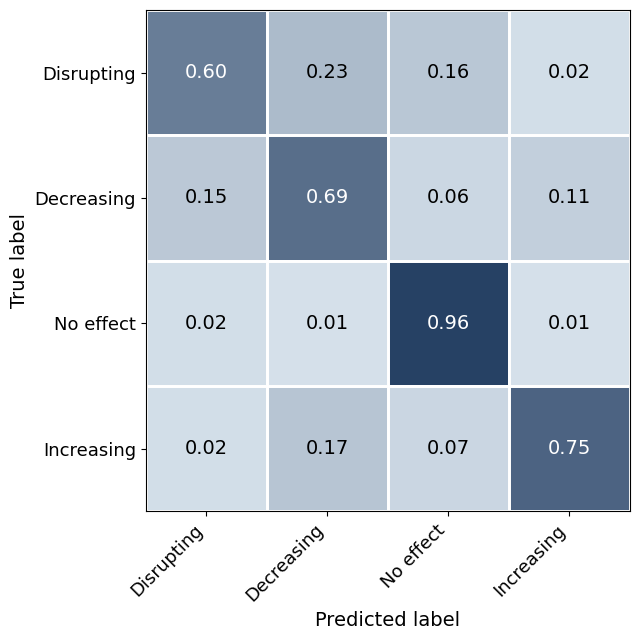

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


conf_mat = np.array([[0.6, 0.23, 0.16, 0.02],
                     [0.15, 0.69, 0.06, 0.11],
                     [0.02, 0.01, 0.96, 0.01],
                     [0.02, 0.17, 0.07, 0.75]])
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']
num_classes = len(class_names)


cmap = LinearSegmentedColormap.from_list("my_blue", ["#d6e1eb", "#1f3a5f"])
norm = Normalize(vmin=0, vmax=1)  # 标准化到 [0,1]


plt.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in range(num_classes):
    for j in range(num_classes):
        color = cmap(norm(conf_mat[i, j]))
        ax.add_patch(
            plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                facecolor=color,
                edgecolor='white', lw=2
            )
        )

        text_color = 'white' if i == j else 'black'
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha='center', va='center',
            fontsize=14,
            color=text_color
        )

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(class_names, fontsize=13)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)

ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xlim(-0.5, num_classes-0.5)
ax.set_ylim(num_classes-0.5, -0.5)

plt.tight_layout()
plt.savefig("confusion_matrix_tappi.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()

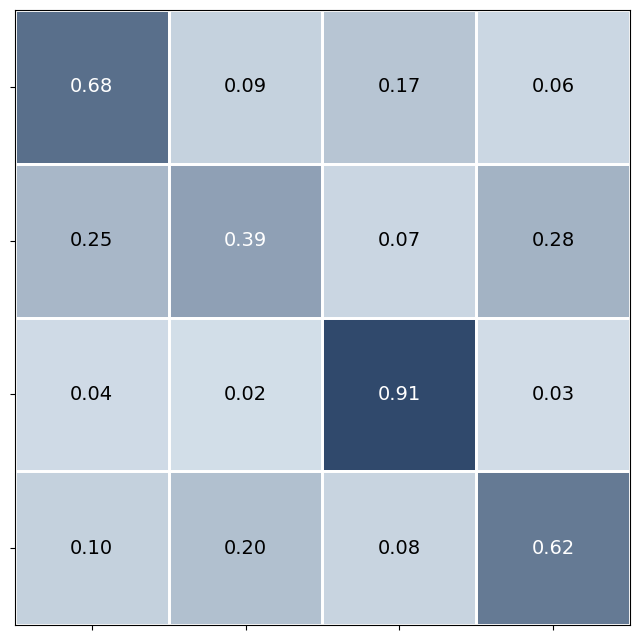

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


conf_mat = np.array([
    [0.68, 0.09, 0.17, 0.06],
    [0.25, 0.39, 0.07, 0.28],
    [0.04, 0.02, 0.91, 0.03],
    [0.10, 0.20, 0.08, 0.62]
])
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']
num_classes = len(class_names)


cmap = LinearSegmentedColormap.from_list("my_blue", ["#d6e1eb", "#1f3a5f"])
norm = Normalize(vmin=0, vmax=1)


plt.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in range(num_classes):
    for j in range(num_classes):
        color = cmap(norm(conf_mat[i, j]))
        ax.add_patch(
            plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                facecolor=color,
                edgecolor='white', lw=2
            )
        )

        text_color = 'white' if i == j else 'black'
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha='center', va='center',
            fontsize=14,
            color=text_color
        )

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
# ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)
# ax.set_yticklabels(class_names, fontsize=13)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_xlabel('Predicted label', fontsize=14)
# ax.set_ylabel('True label', fontsize=14)

ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xlim(-0.5, num_classes-0.5)
ax.set_ylim(num_classes-0.5, -0.5)

plt.tight_layout()
plt.savefig("confusion_matrix_1.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()

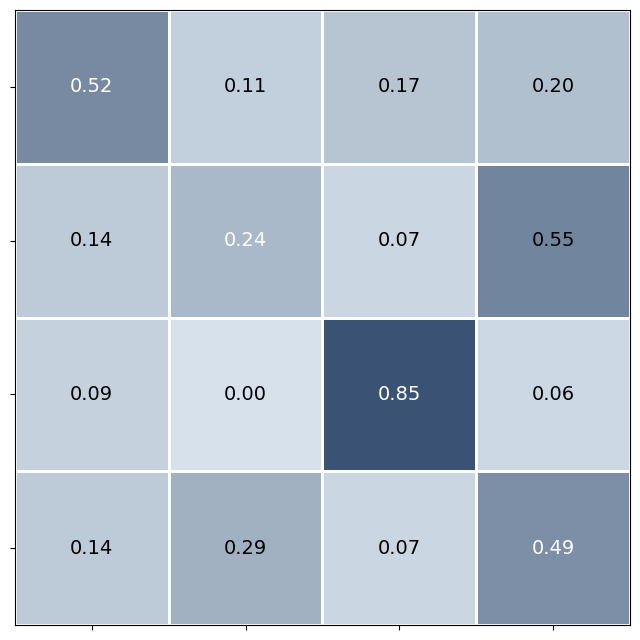

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


conf_mat = np.array([
    [0.52, 0.11, 0.17, 0.20],
    [0.14, 0.24, 0.07, 0.55],
    [0.09, 0.00, 0.85, 0.06],
    [0.14, 0.29, 0.07, 0.49]
])
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']
num_classes = len(class_names)


cmap = LinearSegmentedColormap.from_list("my_blue", ["#d6e1eb", "#1f3a5f"])
norm = Normalize(vmin=0, vmax=1)


plt.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in range(num_classes):
    for j in range(num_classes):
        color = cmap(norm(conf_mat[i, j]))
        ax.add_patch(
            plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                facecolor=color,
                edgecolor='white', lw=2
            )
        )
        text_color = 'white' if i == j else 'black'
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha='center', va='center',
            fontsize=14,
            color=text_color
        )

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
# ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)
# ax.set_yticklabels(class_names, fontsize=13)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_xlabel('Predicted label', fontsize=14)
# ax.set_ylabel('True label', fontsize=14)
ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xlim(-0.5, num_classes-0.5)
ax.set_ylim(num_classes-0.5, -0.5)

plt.tight_layout()
plt.savefig("confusion_matrix_2.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()

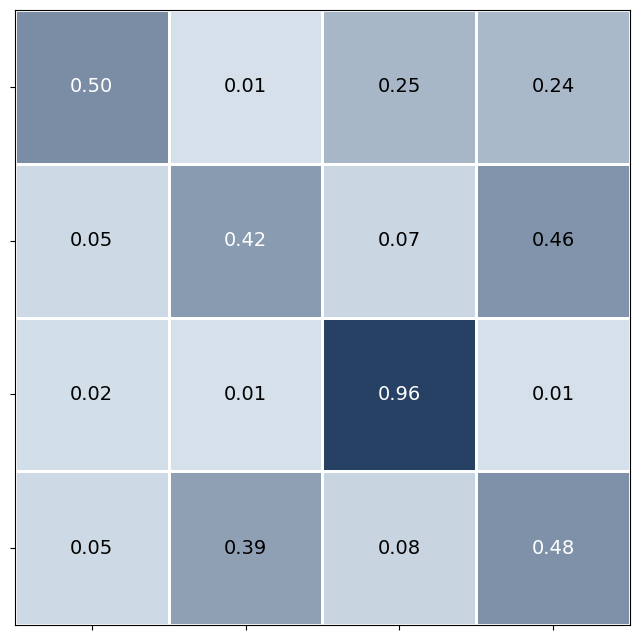

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

conf_mat = np.array([
    [0.50, 0.01, 0.25, 0.24],
    [0.05, 0.42, 0.07, 0.46],
    [0.02, 0.01, 0.96, 0.01],
    [0.05, 0.39, 0.08, 0.48]
])
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']
num_classes = len(class_names)

cmap = LinearSegmentedColormap.from_list("my_blue", ["#d6e1eb", "#1f3a5f"])
norm = Normalize(vmin=0, vmax=1) 

plt.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in range(num_classes):
    for j in range(num_classes):
        color = cmap(norm(conf_mat[i, j]))
        ax.add_patch(
            plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                facecolor=color,
                edgecolor='white', lw=2
            )
        )
        text_color = 'white' if i == j else 'black'
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha='center', va='center',
            fontsize=14,
            color=text_color
        )

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
# ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)
# ax.set_yticklabels(class_names, fontsize=13)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_xlabel('Predicted label', fontsize=14)
# ax.set_ylabel('True label', fontsize=14)

ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xlim(-0.5, num_classes-0.5)
ax.set_ylim(num_classes-0.5, -0.5)

plt.tight_layout()
plt.savefig("confusion_matrix_3.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()

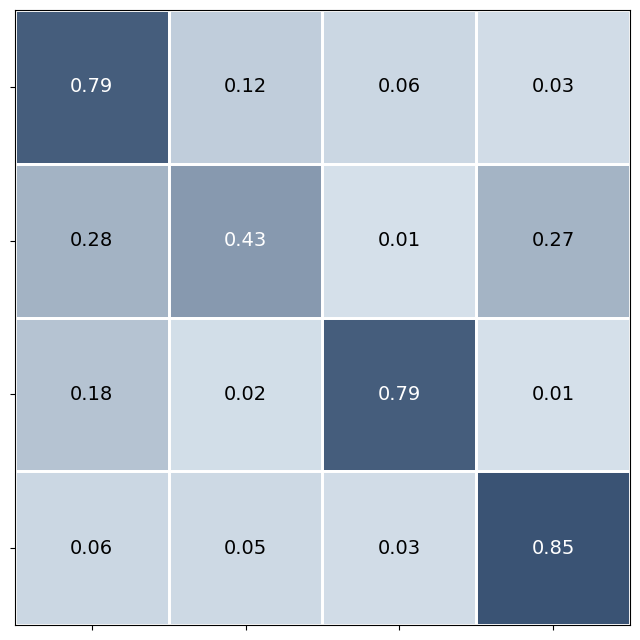

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

conf_mat = np.array([
    [0.79, 0.12, 0.06, 0.03],
    [0.28, 0.43, 0.01, 0.27],
    [0.18, 0.02, 0.79, 0.01],
    [0.06, 0.05, 0.03, 0.85]
])
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']
num_classes = len(class_names)

cmap = LinearSegmentedColormap.from_list("my_blue", ["#d6e1eb", "#1f3a5f"])
norm = Normalize(vmin=0, vmax=1) 

plt.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for i in range(num_classes):
    for j in range(num_classes):
        color = cmap(norm(conf_mat[i, j]))
        ax.add_patch(
            plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                facecolor=color,
                edgecolor='white', lw=2
            )
        )
        text_color = 'white' if i == j else 'black'
        ax.text(
            j, i, f"{conf_mat[i, j]:.2f}",
            ha='center', va='center',
            fontsize=14,
            color=text_color
        )

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
# ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=13)
# ax.set_yticklabels(class_names, fontsize=13)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_xlabel('Predicted label', fontsize=14)
# ax.set_ylabel('True label', fontsize=14)

ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xlim(-0.5, num_classes-0.5)
ax.set_ylim(num_classes-0.5, -0.5)

plt.tight_layout()
plt.savefig("confusion_matrix_4.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()

# Figure 2e was generated from the image below.

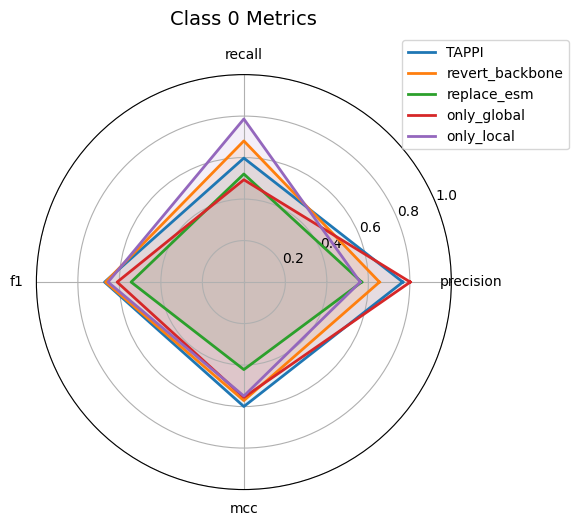

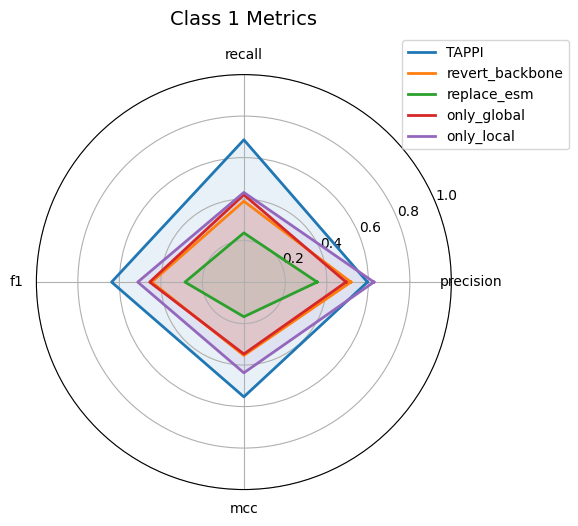

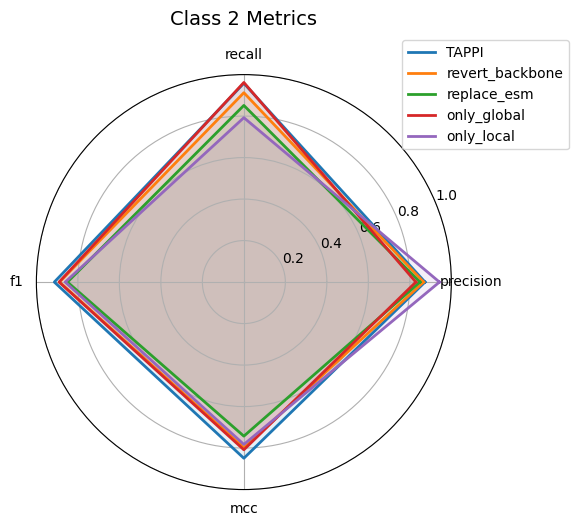

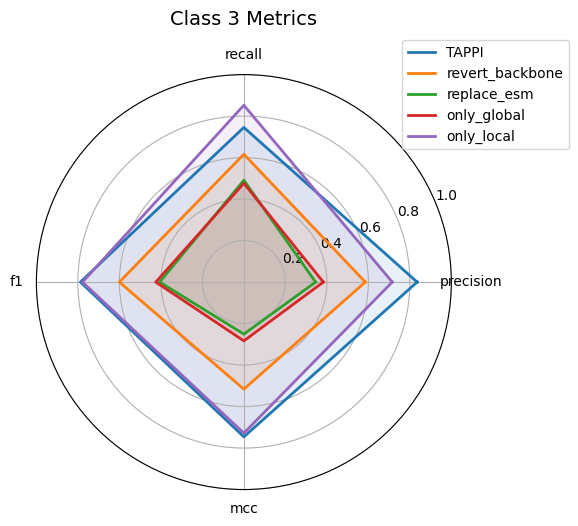

In [16]:
import matplotlib.pyplot as plt
import numpy as np

models = ["TAPPI", "revert_backbone", "replace_esm", "only_global", "only_local"]

metrics = ["precision", "recall", "f1", "mcc"]

data = {
    "TAPPI": [
        [0.7661, 0.5976, 0.6714, 0.5997],
        [0.5958, 0.6857, 0.6376, 0.5531],
        [0.8731, 0.9581, 0.9136, 0.8491],
        [0.8352, 0.7454, 0.7878, 0.7460]
    ],
    "revert_backbone": [
        [0.6536, 0.6803, 0.6667, 0.5713],
        [0.5160, 0.3899, 0.4442, 0.3535],
        [0.8661, 0.9127, 0.8888, 0.7977],
        [0.5854, 0.6162, 0.6004, 0.5161]
    ],
    "replace_esm": [
        [0.5679, 0.5210, 0.5435, 0.4218],
        [0.3534, 0.2371, 0.2838, 0.1671],
        [0.8488, 0.8515, 0.8501, 0.7425],
        [0.3458, 0.4909, 0.4057, 0.2509]
    ],
    "only_global": [
        [0.8020, 0.4932, 0.6108, 0.5556],
        [0.4925, 0.4210, 0.4539, 0.3466],
        [0.8289, 0.9620, 0.8905, 0.8083],
        [0.3831, 0.4761, 0.4246, 0.2835]
    ],
    "only_local": [
        [0.5607, 0.7861, 0.6545, 0.5492],
        [0.6267, 0.4320, 0.5114, 0.4374],
        [0.9427, 0.7924, 0.8611, 0.7824],
        [0.7152, 0.8524, 0.7778, 0.7281]
    ]
}

num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1] 

for class_idx in range(4):
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    
    for model in models:
        values = data[model][class_idx]
        values += values[:1]
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title(f"Class {class_idx} Metrics", size=14, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()